In [68]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np




In [43]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50


In [44]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "data_img",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2110 files belonging to 3 classes.


In [45]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

(32, 256, 256, 3)
[0 1 1 1 1 0 2 0 1 0 1 1 2 1 1 1 0 0 2 2 0 1 0 1 1 1 1 1 0 0 1 1]


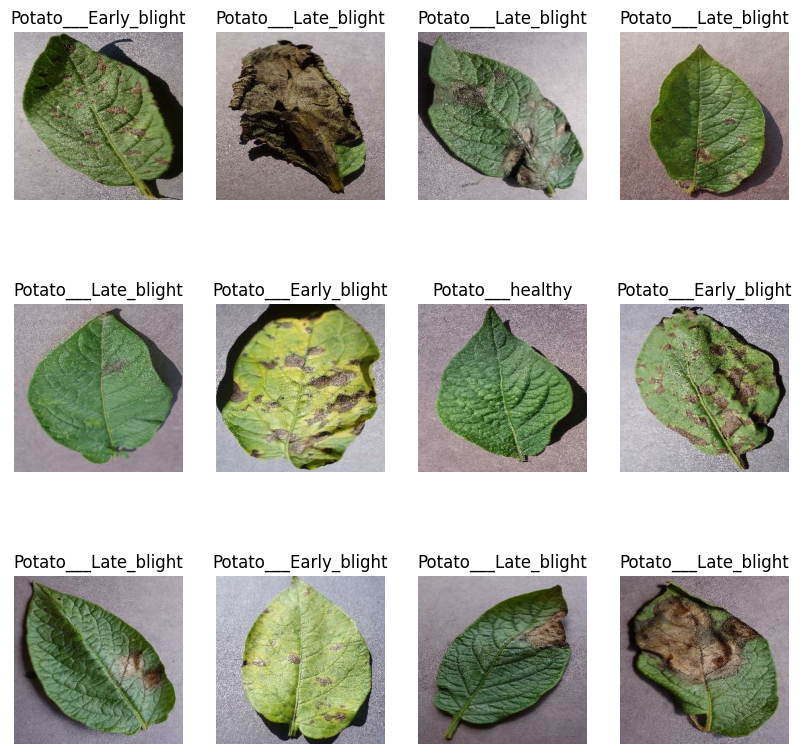

In [46]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")
    

In [47]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1,test_split=0.1,shuffle=True,shuffle_size=10000):

    assert(train_split + test_split + val_split)==1
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size,seed=22)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds


In [48]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [49]:
len(train_ds)

52

In [50]:
len(val_ds)

6

In [51]:
len(test_ds)

8

In [52]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [53]:
resize_and_rescale = tf.keras.Sequential([
    layers.Rescaling(1.0/255),
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)
])


In [54]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),  
    layers.RandomRotation(0.1),                   
    layers.RandomZoom(0.1),                       
    layers.RandomTranslation(0.1, 0.1),           
    layers.RandomContrast(0.1),                   
    layers.RandomBrightness(0.1),                 
    layers.RandomHeight(0.1),                    
    layers.RandomWidth(0.1),                      
])

In [55]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [56]:
model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax'),
])


model.summary()

d:\PROJECT\project1\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)



In [58]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 33s 555ms/step - accuracy: 0.5427 - loss: 0.8750 - val_accuracy: 0.6979 - val_loss: 0.7692
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 527ms/step - accuracy: 0.7335 - loss: 0.6279 - val_accuracy: 0.6719 - val_loss: 0.7010
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 540ms/step - accuracy: 0.8225 - loss: 0.4334 - val_accuracy: 0.7240 - val_loss: 0.5270
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 29s 554ms/step - accuracy: 0.8670 - loss: 0.3355 - val_accuracy: 0.7708 - val_loss: 0.6822
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 532ms/step - accuracy: 0.8742 - loss: 0.3190 - val_accuracy: 0.8542 - val_loss: 0.6171
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8839 - loss: 0.2843 - val_accuracy: 0.8594 - val_loss: 0.3193
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9007 - loss: 0.2500 - val_accuracy: 0.8854 - val_loss: 0.2733
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9049 - loss: 0.2369 - val_accuracy: 0.

In [59]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 578ms/step - accuracy: 0.8750 - loss: 0.3814


In [60]:
scores

[0.38140225410461426, 0.875]

In [61]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 52}

In [62]:
history.history['accuracy']

[0.5427196025848389,
 0.7334536910057068,
 0.8225030303001404,
 0.8670276999473572,
 0.8742479085922241,
 0.8838748335838318,
 0.9007220268249512,
 0.9049338102340698,
 0.9181708693504333,
 0.888688325881958,
 0.9133573770523071,
 0.9253910779953003,
 0.9344163537025452,
 0.938026487827301,
 0.948856770992279,
 0.945246696472168,
 0.9374247789382935,
 0.9458483457565308,
 0.9560770392417908,
 0.9578820466995239,
 0.9626955389976501,
 0.9614921808242798,
 0.9572803974151611,
 0.977135956287384,
 0.9584837555885315,
 0.973525881767273,
 0.9705174565315247,
 0.9614921808242798,
 0.9729241728782654,
 0.9825511574745178,
 0.9795427322387695,
 0.966305673122406,
 0.9596871137619019,
 0.9855595827102661,
 0.9759325981140137,
 0.9741275310516357,
 0.9819494485855103,
 0.9885680079460144,
 0.9819494485855103,
 0.9777376651763916,
 0.9849578738212585,
 0.977135956287384,
 0.9819494485855103,
 0.9831528067588806,
 0.9831528067588806,
 0.978941023349762,
 0.9795427322387695,
 0.987364649772644,
 0

In [63]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

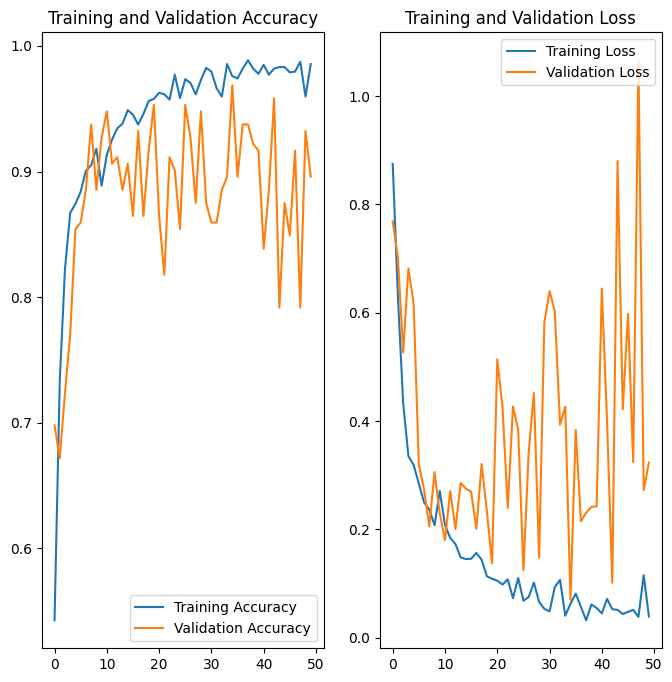

In [64]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

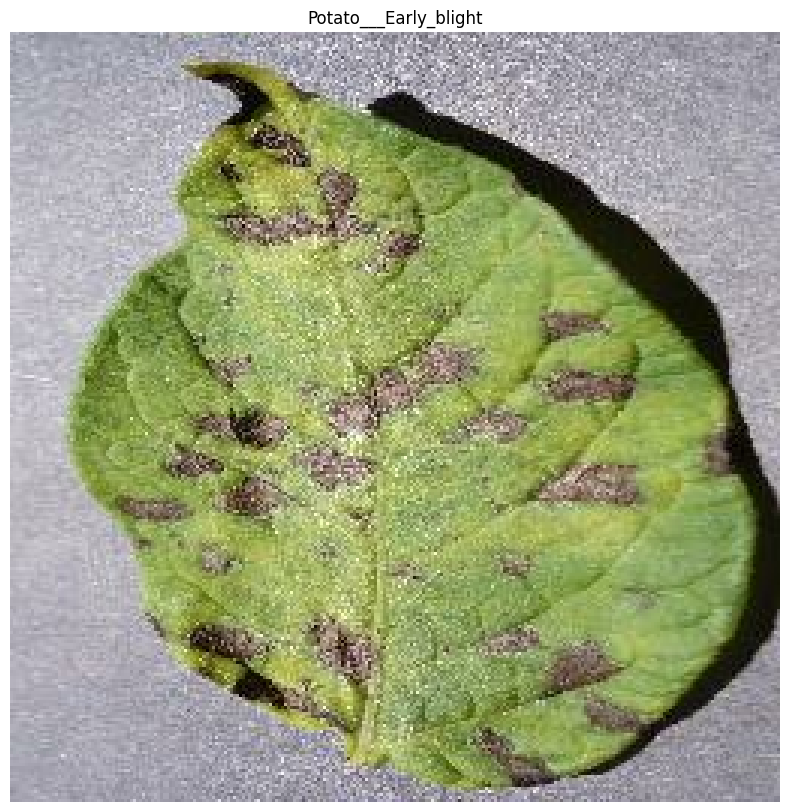

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Potato___Early_blight


In [83]:
for image_batch, labels_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    plt.figure(figsize=(10, 10))
    plt.imshow(first_image)
    plt.title(class_names[labels_batch[0]])
    plt.axis('off')
    plt.show()

batch_predictions = model.predict(image_batch)
print(class_names[np.argmax(batch_predictions[0])])

In [84]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


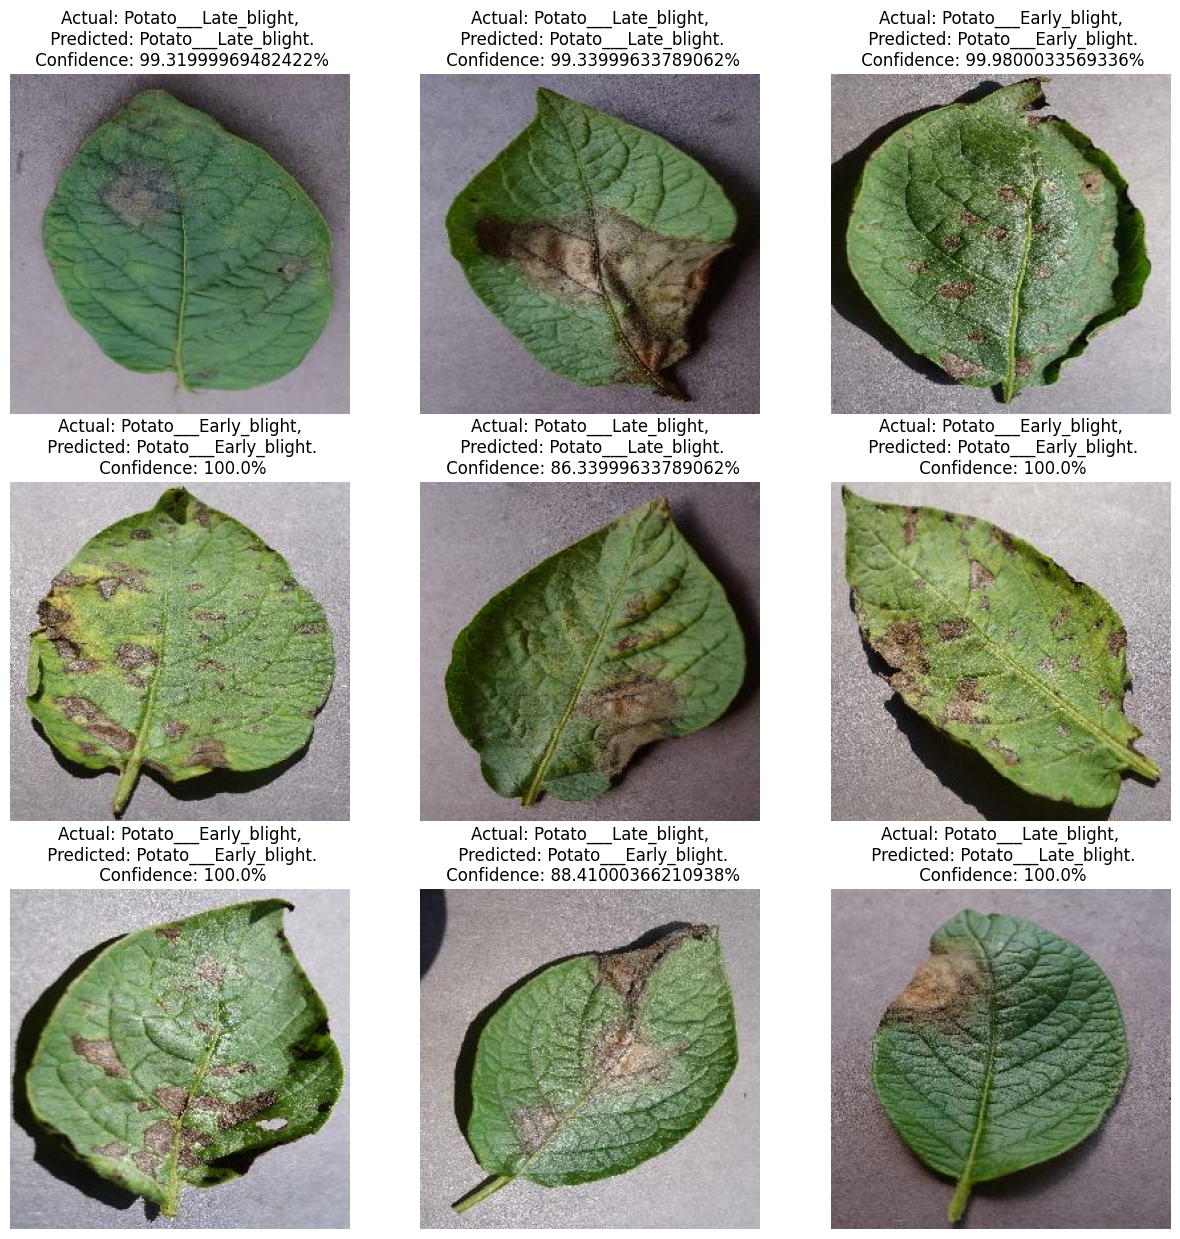

In [85]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [93]:
import os

# get next model version
model_version = max([int(i) for i in os.listdir("models") if i.isdigit()] + [0]) + 1

# create new version folder
model_dir = f"models/{model_version}"
os.makedirs(model_dir, exist_ok=True)

# save model
model.save(f"{model_dir}/potatoes.h5")